<a href="https://colab.research.google.com/github/yangyuwang/DL_final_project/blob/main/TGCN_for_ArtistNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch_geometric torch_geometric_temporal

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
nodes_df = pd.read_csv("/content/drive/My Drive/GNN/node_summary.csv")
edges_df = pd.read_csv("/content/drive/My Drive/GNN/edge_list.csv")

nodes_df.head()

,name,Year,All_Styles
0,3D,1983,Street art
1,3D,1984,Street art
2,3D,1985,Street art
3,3D,1986,Street art
4,3D,1987,Street art


In [ ]:
edges_df.head()

,from,to,type
0,Abbott Handerson Thayer,Jean-Leon Gerome,Friendship
1,Abbott Handerson Thayer,Frank W. Benson,Friendship
2,Ad Reinhardt,Jackson Pollock,Friendship
3,Adam van Noort,Maarten de Vos,Friendship
4,Agnolo Bronzino,Alessandro Allori,Friendship


In [ ]:
!sed -i 's/from torch_geometric.utils.to_dense_adj import to_dense_adj/from torch_geometric.utils import to_dense_adj/g' /usr/local/lib/python3.11/dist-packages/torch_geometric_temporal/nn/attention/tsagcn.py

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric_temporal.signal import DynamicGraphTemporalSignal

artist_to_index = {artist: index for index, artist in enumerate(set(nodes_df['name']))}

nodes_df['id'] = nodes_df['name'].map(artist_to_index)

In [ ]:
edge_index = []
for index, row in edges_df.iterrows():
  source_artist = row['from']
  target_artist = row['to']
  if source_artist in artist_to_index and target_artist in artist_to_index:  # Handle potential missing artists
    edge_index.append([artist_to_index[source_artist], artist_to_index[target_artist]])
    edge_index.append([artist_to_index[target_artist], artist_to_index[source_artist]]) # Undirected edge


In [ ]:
def create_style_mapping(df, column_name='All_Styles'):
    styles_set = set()
    for styles in df[column_name]:
        for style in styles.split(','):
            styles_set.add(style.strip())
    style_to_index = {style: idx for idx, style in enumerate(sorted(styles_set))}
    return style_to_index

style_to_index = create_style_mapping(nodes_df, 'All_Styles')
print("Style mapping:", style_to_index)

Style mapping: {'Abstract Art': 0, 'Abstract Expressionism': 1, 'Academicism': 2, 'Action painting': 3, 'American Realism': 4, 'Analytical Cubism': 5, 'Analytical Realism': 6, 'Art Brut': 7, 'Art Deco': 8, 'Art Informel': 9, 'Art Nouveau (Modern)': 10, 'Art Singulier': 11, 'Automatic Painting': 12, 'Baroque': 13, 'Biedermeier': 14, 'Byzantine': 15, 'Cartographic Art': 16, 'Classical Realism': 17, 'Classicism': 18, 'Cloisonnism': 19, 'Color Field Painting': 20, 'Conceptual Art': 21, 'Concretism': 22, 'Confessional Art': 23, 'Constructivism': 24, 'Contemporary': 25, 'Contemporary Realism': 26, 'Costumbrismo': 27, 'Cubism': 28, 'Cubo-Expressionism': 29, 'Cubo-Futurism': 30, 'Cyber Art': 31, 'Dada': 32, 'Digital Art': 33, 'Divisionism': 34, 'Documentary photography': 35, 'Early Christian': 36, 'Early Renaissance': 37, 'Environmental (Land) Art': 38, 'Excessivism': 39, 'Existential Art': 40, 'Expressionism': 41, 'Fantastic Realism': 42, 'Fantasy Art': 43, 'Fauvism': 44, 'Feminist Art': 45, 

In [ ]:
def create_multi_hot(label_string, mapping):
    multi_hot = [0] * len(mapping)
    for style in label_string.split(','):
        style = style.strip()
        if style in mapping:
            multi_hot[mapping[style]] = 1
    return multi_hot

torch.Size([85771, 172])


In [ ]:
Year_list = sorted(list(set(nodes_df["Year"])))

In [ ]:
len(edge_index)

12568

In [ ]:
from tqdm import tqdm

edge_years = []
years = []
features = []
labels = []
ygroup = nodes_df.groupby('Year')
num_nodes = len(artist_to_index)
# Assuming you know the number of styles from your mapping
num_styles = len(style_to_index)

# Loop over your list of years (excluding the last two, as in your snippet)
for y in tqdm(Year_list[:-2]):
    # Get the group for year y and y+1
    ycgroup = ygroup.get_group(y)
    yfgroup = ygroup.get_group(y + 1)
    id_list = list(ycgroup["id"])

    # Filter edges for current snapshot
    edge_year = list(filter(lambda edge: edge[0] in id_list and edge[1] in id_list, edge_index))
    if edge_year:
        edge_years.append(edge_year)
        years.append(y)
        features_id = []
        labels_id = []

        for idx in range(num_nodes):
            # For features: Check if node idx is present in ycgroup
            if idx in list(ycgroup["id"]):
                # Assuming each id appears only once in the group
                feat = ycgroup[ycgroup["id"] == idx]["All_Styles"].apply(lambda x: create_multi_hot(x, style_to_index)).tolist()
                #feat = feat.append(other_feat)
                # If feat is a list with one element, take that element:
                if feat:
                    features_id.append(feat[0])
                else:
                    features_id.append([0] * num_styles)
            else:
                # Default: node not present, so assign a zero vector
                features_id.append([0] * num_styles)


            # For labels: Check if node idx is present in yfgroup
            if idx in list(yfgroup["id"]):
                lab = yfgroup[yfgroup["id"] == idx]["All_Styles"].apply(lambda x: create_multi_hot(x, style_to_index)).tolist()
                if lab:
                    labels_id.append(lab[0])
                else:
                    labels_id.append([0] * num_styles)
            else:
                labels_id.append([0] * num_styles)

        features.append(features_id)
        labels.append(labels_id)


100%|██████████| 623/623 [03:17<00:00,  3.16it/s]


In [225]:
len(features[0][0])

172

In [223]:
import torch
from torch_geometric_temporal.signal import DynamicGraphTemporalSignal

# Convert each snapshot's edge list into a tensor of shape [2, num_edges]
edge_indices_tensors = []
edge_weights_tensors = []

for snapshot_edges in edge_years:
    # snapshot_edges is a list of edges, where each edge is [from, to]
    if len(snapshot_edges) > 0:
        # Convert to a tensor and transpose so that the shape becomes [2, num_edges]
        edge_index = torch.tensor(snapshot_edges, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    edge_indices_tensors.append(edge_index)

    # Create a tensor of edge weights (all ones) with length equal to the number of edges
    edge_weights_tensors.append(torch.ones(edge_index.size(1), dtype=torch.float))

# Convert your features and labels lists to tensors if you haven't done so already.
# They should already be lists of lists (or arrays) with shape [num_nodes, num_features] and [num_nodes, num_labels]
# For instance, you can do:
features_tensors = [torch.tensor(feat, dtype=torch.float) for feat in features]
labels_tensors   = [torch.tensor(lbl, dtype=torch.float) for lbl in labels]


In [294]:
import torch
import torch.nn.functional as F
from torch_geometric_temporal.nn.recurrent import TGCN

# Define a model that processes a single snapshot using TGCN.
class TGCNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(TGCNModel, self).__init__()
        self.tgcn1 = TGCN(in_channels, hidden_channels)
        self.tgcn2 = TGCN(hidden_channels, hidden_channels)
        self.linear = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_weight):
        h = self.tgcn1(x, edge_index, edge_weight)
        h = self.tgcn2(h, edge_index, edge_weight)
        return self.linear(h)  # returns logits for each class

num_snapshots = len(features_tensors)

# Get dimensions from the first snapshot (assuming consistency across snapshots)
in_channels = features_tensors[0].shape[1]       # number of node features
out_channels = 172  # 172 classes for classification
hidden_channels = 32  # you can adjust this as needed

# Instantiate the model and optimizer.
model = TGCNModel(in_channels, hidden_channels, out_channels)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Define the loss function for multiclass classification.
criterion = torch.nn.CrossEntropyLoss()

num_epochs = 20

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    # Process each snapshot independently.
    for t in range(num_snapshots):
        x = features_tensors[t]             # shape: [num_nodes, in_channels]
        edge_index = edge_indices_tensors[t]  # shape: [2, num_edges]
        edge_weight = edge_weights_tensors[t] # shape: [num_edges]
        y = labels_tensors[t]                 # shape: [num_nodes] with class indices

        optimizer.zero_grad()
        out = model(x, edge_index, edge_weight)  # out: [num_nodes, 172]
        # CrossEntropyLoss expects target shape [num_nodes] (class indices)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / num_snapshots
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")


Epoch 1/20, Loss: 0.2003
Epoch 2/20, Loss: 0.1630
Epoch 3/20, Loss: 0.1505
Epoch 4/20, Loss: 0.1396
Epoch 5/20, Loss: 0.1313
Epoch 6/20, Loss: 0.1273
Epoch 7/20, Loss: 0.1235
Epoch 8/20, Loss: 0.1209
Epoch 9/20, Loss: 0.1179
Epoch 10/20, Loss: 0.1171
Epoch 11/20, Loss: 0.1160
Epoch 12/20, Loss: 0.1163
Epoch 13/20, Loss: 0.1148
Epoch 14/20, Loss: 0.1126
Epoch 15/20, Loss: 0.1119
Epoch 16/20, Loss: 0.1122
Epoch 17/20, Loss: 0.1116
Epoch 18/20, Loss: 0.1112
Epoch 19/20, Loss: 0.1113
Epoch 20/20, Loss: 0.1113


In [295]:

import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for t in range(num_snapshots):
        x = features_tensors[t]
        edge_index = edge_indices_tensors[t]
        edge_weight = edge_weights_tensors[t]
        y = labels_tensors[t]

        out = model(x, edge_index, edge_weight)
        _, predicted_labels = torch.max(out, 1)

        _, true_labels = torch.max(y, 1)

        all_predictions.extend(predicted_labels.tolist())
        all_labels.extend(true_labels.tolist())

accuracy = accuracy_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted') # Use weighted for multiclass
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.0379
F1 Score: 0.0385
Precision: 0.6397
Recall: 0.0379


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [296]:
import matplotlib.pyplot as plt

model.eval()

predicted_classes_list = []
actual_classes_list = []
years_plot = []

for t in range(num_snapshots):
    x = features_tensors[t]
    edge_index = edge_indices_tensors[t]
    edge_weight = edge_weights_tensors[t]
    y = labels_tensors[t]

    with torch.no_grad():
        out = model(x, edge_index, edge_weight)

    predicted_classes = out.argmax(dim=1)

    actual_classes = y.argmax(dim=1)

    predicted_classes_list.extend(predicted_classes.tolist())
    actual_classes_list.extend(actual_classes.tolist())

    years_plot.extend([years[t]] * x.size(0))

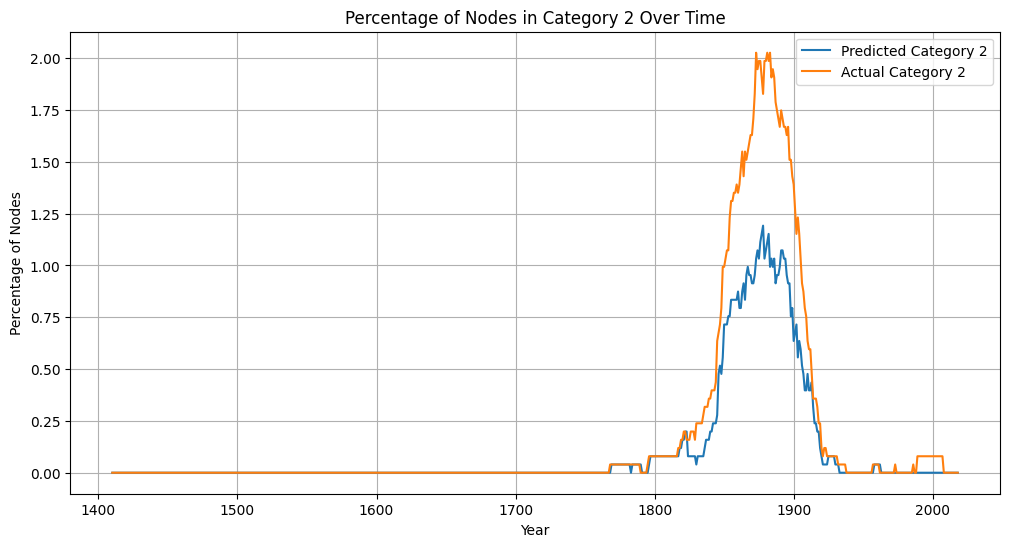

In [298]:
target_category = 2

years_unique = sorted(list(set(years_plot)))
yearly_predicted_percentage = []
yearly_actual_percentage = []

for year in years_unique:
    indices = [i for i, y in enumerate(years_plot) if y == year]
    if indices:
        predicted_for_year = [predicted_classes_list[i] for i in indices]
        actual_for_year = [actual_classes_list[i] for i in indices]
        predicted_pct = sum(1 for p in predicted_for_year if p == target_category) / len(predicted_for_year)
        actual_pct = sum(1 for a in actual_for_year if a == target_category) / len(actual_for_year)
    else:
        predicted_pct = 0
        actual_pct = 0
    yearly_predicted_percentage.append(predicted_pct * 100)  # as percentage
    yearly_actual_percentage.append(actual_pct * 100)

plt.figure(figsize=(12, 6))
plt.plot(years_unique, yearly_predicted_percentage, label=f"Predicted Category {target_category}")
plt.plot(years_unique, yearly_actual_percentage, label=f"Actual Category {target_category}")
plt.xlabel("Year")
plt.ylabel("Percentage of Nodes")
plt.title(f"Percentage of Nodes in Category {target_category} Over Time")
plt.legend()
plt.grid(True)
plt.show()
